# Community Detection

In [ ]:
!pip install igraph

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.6 MB/s eta 0:00:00


In [ ]:
import pickle
import pandas as pd
import numpy as np
import random
random.seed(2026)
np.random.seed(2026)
import igraph as ig
import networkx as nx
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def leiden(G, seed=2026, resolution=1.0, weight="weight", objective="modularity", beta=0.1, n_iterations=200):
    random.seed(seed)

    nodes = sorted(G.nodes())
    node_to_index = {n: i for i, n in enumerate(nodes)}
    edges = list(G.edges(data=True))
    g = ig.Graph(n=len(G.nodes()), edges=[(node_to_index[u], node_to_index[v]) for u, v, _ in edges])
    g.es["weight"] = [similarity["weight"] for _, _, similarity in edges]

    partition = g.community_leiden(objective_function=objective, weights=g.es["weight"], resolution=resolution, beta=beta, n_iterations=n_iterations)
    communities = [set(nodes[v] for v in community) for community in partition]

    return communities

In [ ]:
def tune_algorithm(G, algorithm, seed=2026, n_trials=50):
    def objective(trial):
        if algorithm == "CNM":
            communities = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "Louvain":
            communities = list(nx.algorithms.community.louvain_communities(G, seed=seed, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "Leiden":
            beta = trial.suggest_float("beta", 0.1, 10, log=True)
            communities = list(leiden(G, seed=seed, weight="weight", objective="modularity", beta=beta, n_iterations=200))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "FLPA":
            communities = list(nx.algorithms.community.fast_label_propagation_communities(G, seed=seed, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")


    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    best_trial = study.best_trial
    return best_trial.value, best_trial.params

In [ ]:
def evaluate_graph(graph_dict, dataset, algorithm, seed=2026, n_trials=50):
    records = []

    for method in graph_dict[dataset]:
        for measure, G in graph_dict[dataset][method].items():

            best_score, best_params = tune_algorithm(G, algorithm, seed=seed, n_trials=n_trials)
            parameters = [f"{k}={v}" for k, v in best_params.items()]

            records.append({
                "Dataset": dataset,
                "Method": method,
                "Measure": measure,
                "Algorithm": algorithm,
                "Modularity": best_score,
                "Parameters": parameters
            })

    df = pd.DataFrame(records)

    modularity_values = df["Modularity"].values
    modularity_values = np.where(modularity_values < 0, 0, modularity_values)
    df["Modularity"] = modularity_values

    return df

In [ ]:
dataset_order = ["SemEval-2010", "NUS", "Inspec", "KDD", "WWW", "SemEval-2017", "DUC-2001", "500N-KP-Crowd"]
method_order = ["TF", "TfIdf", "KPMiner", "YAKE", "TextRank1", "SingleRank", "PositionRank", "KeyBERT", "MDERANK", "LMRANK"]
measure_order = ["CF", "Dice", "Jaccard", "Cosine"]
algorithm_order = ["CNM", "Louvain", "Leiden", "FLPA"]

In [ ]:
all_results = []

with open("Graph_dict.pkl", "rb") as f:
    graph_dict = pickle.load(f)

for dataset in dataset_order:
    for algorithm in algorithm_order:

        df = evaluate_graph(graph_dict, dataset, algorithm, seed=2026, n_trials=50)
        all_results.append(df)

        results_df = pd.concat(all_results, ignore_index=True)

In [ ]:
results_df['Dataset'] = pd.Categorical(results_df['Dataset'], categories=dataset_order, ordered=True)
results_df['Method'] = pd.Categorical(results_df['Method'], categories=method_order, ordered=True)
results_df['Measure'] = pd.Categorical(results_df['Measure'], categories=measure_order, ordered=True)
results_df['Algorithm'] = pd.Categorical(results_df['Algorithm'], categories=algorithm_order, ordered=True)

results_df = results_df.sort_values(by=['Dataset', 'Method', 'Measure', 'Algorithm'])
results_df = results_df.reset_index(drop=True)

In [ ]:
results_df

,Dataset,Method,Measure,Algorithm,Modularity,Parameters
0,SemEval-2010,TF,CF,CNM,0.342335,[]
1,SemEval-2010,TF,CF,Louvain,0.365538,[]
2,SemEval-2010,TF,CF,Leiden,0.365538,[beta=0.2745941431317787]
3,SemEval-2010,TF,CF,FLPA,0.000000,[]
4,SemEval-2010,TF,Dice,CNM,0.333987,[]
...,...,...,...,...,...,...
1083,500N-KP-Crowd,LMRANK,Jaccard,FLPA,0.344476,[]
1084,500N-KP-Crowd,LMRANK,Cosine,CNM,0.400862,[]
1085,500N-KP-Crowd,LMRANK,Cosine,Louvain,0.400862,[]
1086,500N-KP-Crowd,LMRANK,Cosine,Leiden,0.401744,[beta=0.2745941431317787]


In [ ]:
with open("Edge_Weighting_results.pkl", 'rb') as f:
    Edge_Weighting_results = pickle.load(f)

In [ ]:
Edge_Weighting_results

,Dataset,Method,Measure,IP1,IP2,RI
0,SemEval-2010,TF,CF,0.000000,0.000000,0.000000
1,SemEval-2010,TF,Dice,0.000000,0.000000,0.000000
2,SemEval-2010,TF,Jaccard,0.000000,0.000000,0.000000
3,SemEval-2010,TF,Cosine,0.000000,0.000000,0.000000
4,SemEval-2010,TfIdf,CF,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
263,SemEval-2017,KeyBERT,Cosine,0.284402,0.500000,0.271728
264,SemEval-2017,MDERANK,CF,0.086750,0.304965,0.010255
265,SemEval-2017,MDERANK,Dice,0.206127,0.500000,0.252661
266,SemEval-2017,MDERANK,Jaccard,0.206127,0.500000,0.252661


In [ ]:
key_columns = ['Dataset', 'Method', 'Measure']

merged_df = pd.merge(
    results_df,
    Edge_Weighting_results[key_columns + ['IP1', 'IP2', 'RI']],
    on=key_columns,
    how='left'
)

merged_df[['IP1', 'IP2', 'RI']] = merged_df[['IP1', 'IP2', 'RI']].fillna(0)
Community_Detection_results = merged_df

In [ ]:
Community_Detection_results

,Dataset,Method,Measure,Algorithm,Modularity,Parameters,IP1,IP2,RI
0,SemEval-2010,TF,CF,CNM,0.342335,[],0.0,0.0,0.0
1,SemEval-2010,TF,CF,Louvain,0.365538,[],0.0,0.0,0.0
2,SemEval-2010,TF,CF,Leiden,0.365538,[beta=0.2745941431317787],0.0,0.0,0.0
3,SemEval-2010,TF,CF,FLPA,0.000000,[],0.0,0.0,0.0
4,SemEval-2010,TF,Dice,CNM,0.333987,[],0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1083,500N-KP-Crowd,LMRANK,Jaccard,FLPA,0.344476,[],0.0,0.0,0.0
1084,500N-KP-Crowd,LMRANK,Cosine,CNM,0.400862,[],0.0,0.0,0.0
1085,500N-KP-Crowd,LMRANK,Cosine,Louvain,0.400862,[],0.0,0.0,0.0
1086,500N-KP-Crowd,LMRANK,Cosine,Leiden,0.401744,[beta=0.2745941431317787],0.0,0.0,0.0


In [ ]:
with open("Community_Detection_results.pkl", "wb") as f:
    pickle.dump(Community_Detection_results, f)

# Summary

In [ ]:
summary = Community_Detection_results.groupby(['Dataset', 'Algorithm'])['Modularity'].agg(['mean', 'std'])

summary_unstacked = summary.unstack(level='Algorithm')

summary_table = summary_unstacked.stack(level=0, future_stack=True).reset_index()
summary_table.rename(columns={'level_1': 'Stat'}, inplace=True)

dataset_order = ['SemEval-2010', 'NUS', 'Inspec', 'KDD', 'WWW', 'SemEval-2017', 'DUC-2001', '500N-KP-Crowd']
summary_table['Dataset'] = pd.Categorical(summary_table['Dataset'], categories=dataset_order, ordered=True)
summary_table['Stat'] = pd.Categorical(summary_table['Stat'], categories=['mean', 'std'], ordered=True)

summary_table = summary_table.sort_values(['Dataset', 'Stat']).reset_index(drop=True)
summary_table_rounded = summary_table.round(3)

/tmp/ipython-input-379/2613564543.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = Community_Detection_results.groupby(['Dataset', 'Algorithm'])['Modularity'].agg(['mean', 'std'])


In [ ]:
summary_table_rounded

Algorithm,Dataset,Stat,CNM,Louvain,Leiden,FLPA
0,SemEval-2010,mean,0.312,0.317,0.321,0.117
1,SemEval-2010,std,0.075,0.076,0.075,0.118
2,NUS,mean,0.348,0.351,0.354,0.162
3,NUS,std,0.094,0.094,0.094,0.187
4,Inspec,mean,0.402,0.398,0.408,0.228
5,Inspec,std,0.124,0.123,0.123,0.196
6,KDD,mean,0.346,0.349,0.353,0.198
7,KDD,std,0.135,0.136,0.134,0.183
8,WWW,mean,0.391,0.388,0.394,0.245
9,WWW,std,0.130,0.130,0.130,0.207


# Normality Test

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
norm_results = []

for ds_name, ds_group in Community_Detection_results.groupby('Dataset'):
    for algo_name, algo_group in ds_group.groupby('Algorithm'):
        observations = algo_group['Modularity']

        z_scores = (observations - observations.mean()) / observations.std()
        stat, p_val = stats.kstest(z_scores, 'norm')

        norm_results.append({
            'Dataset': ds_name,
            'Method': algo_name,
            'K-S Stat': f"{stat:.4f}",
            'p-value': f"{p_val:.4e}",
            'Is_Normal': 'Yes' if p_val > 0.05 else 'No'
        })

norm_summary = pd.DataFrame(norm_results)

/tmp/ipython-input-379/4067043219.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for algo_name, algo_group in ds_group.groupby('Algorithm'):


In [ ]:
norm_summary

,Dataset,Method,K-S Stat,p-value,Is_Normal
0,500N-KP-Crowd,CNM,0.0948,9.1025e-01,Yes
1,500N-KP-Crowd,Louvain,0.1230,6.7260e-01,Yes
2,500N-KP-Crowd,Leiden,0.1151,7.4791e-01,Yes
3,500N-KP-Crowd,FLPA,0.1325,5.8177e-01,Yes
4,DUC-2001,CNM,0.1554,3.8301e-01,Yes
5,DUC-2001,Louvain,0.1356,5.5260e-01,Yes
6,DUC-2001,Leiden,0.1411,5.0284e-01,Yes
7,DUC-2001,FLPA,0.1994,1.3651e-01,Yes
8,Inspec,CNM,0.1462,4.5802e-01,Yes
9,Inspec,Louvain,0.0982,8.8730e-01,Yes


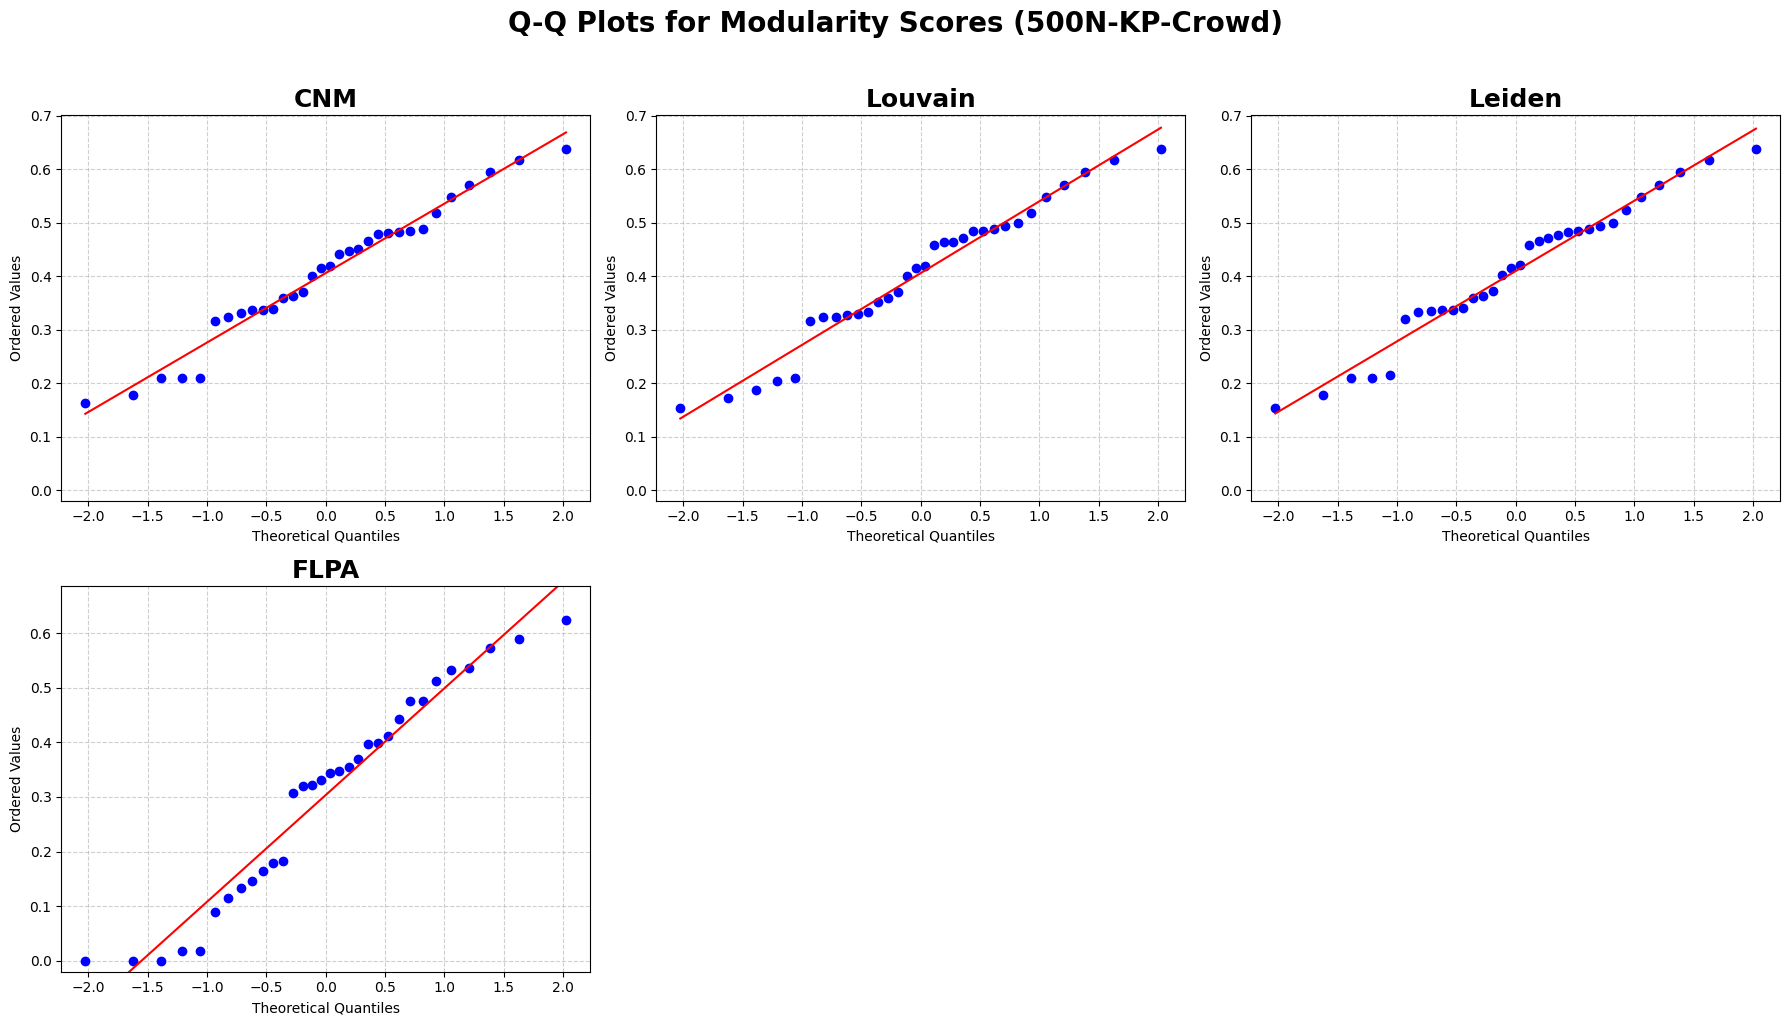

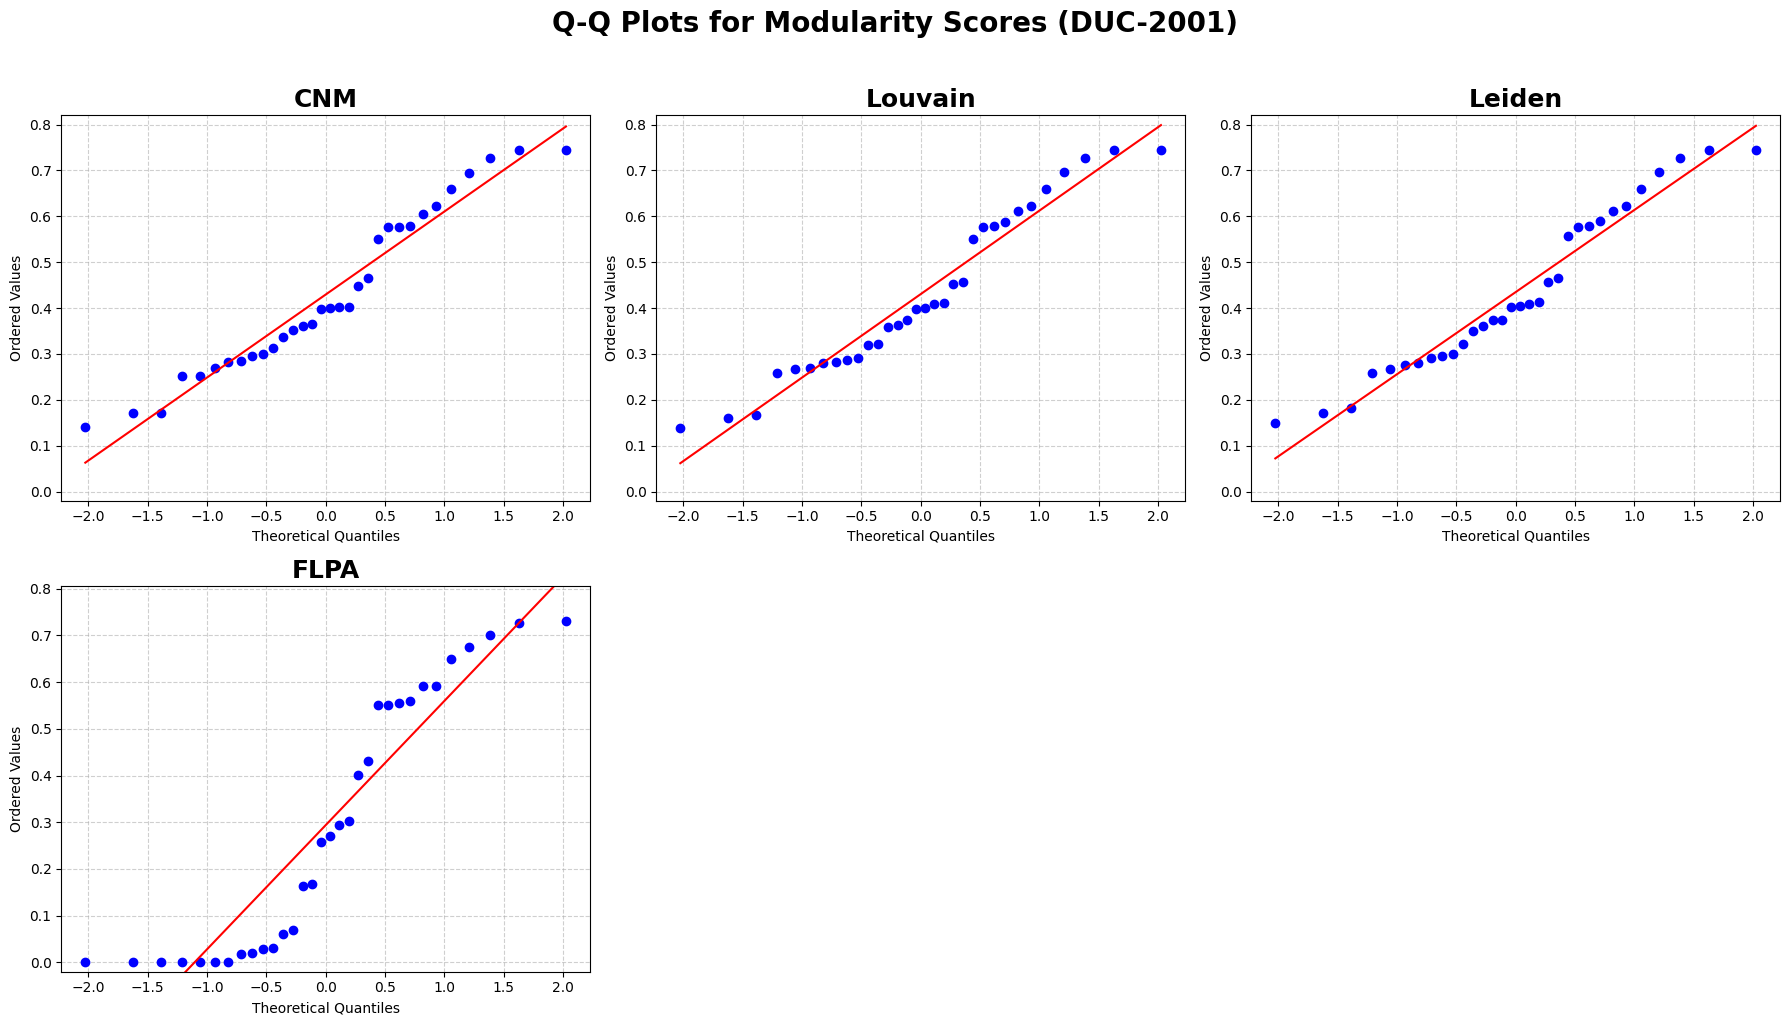

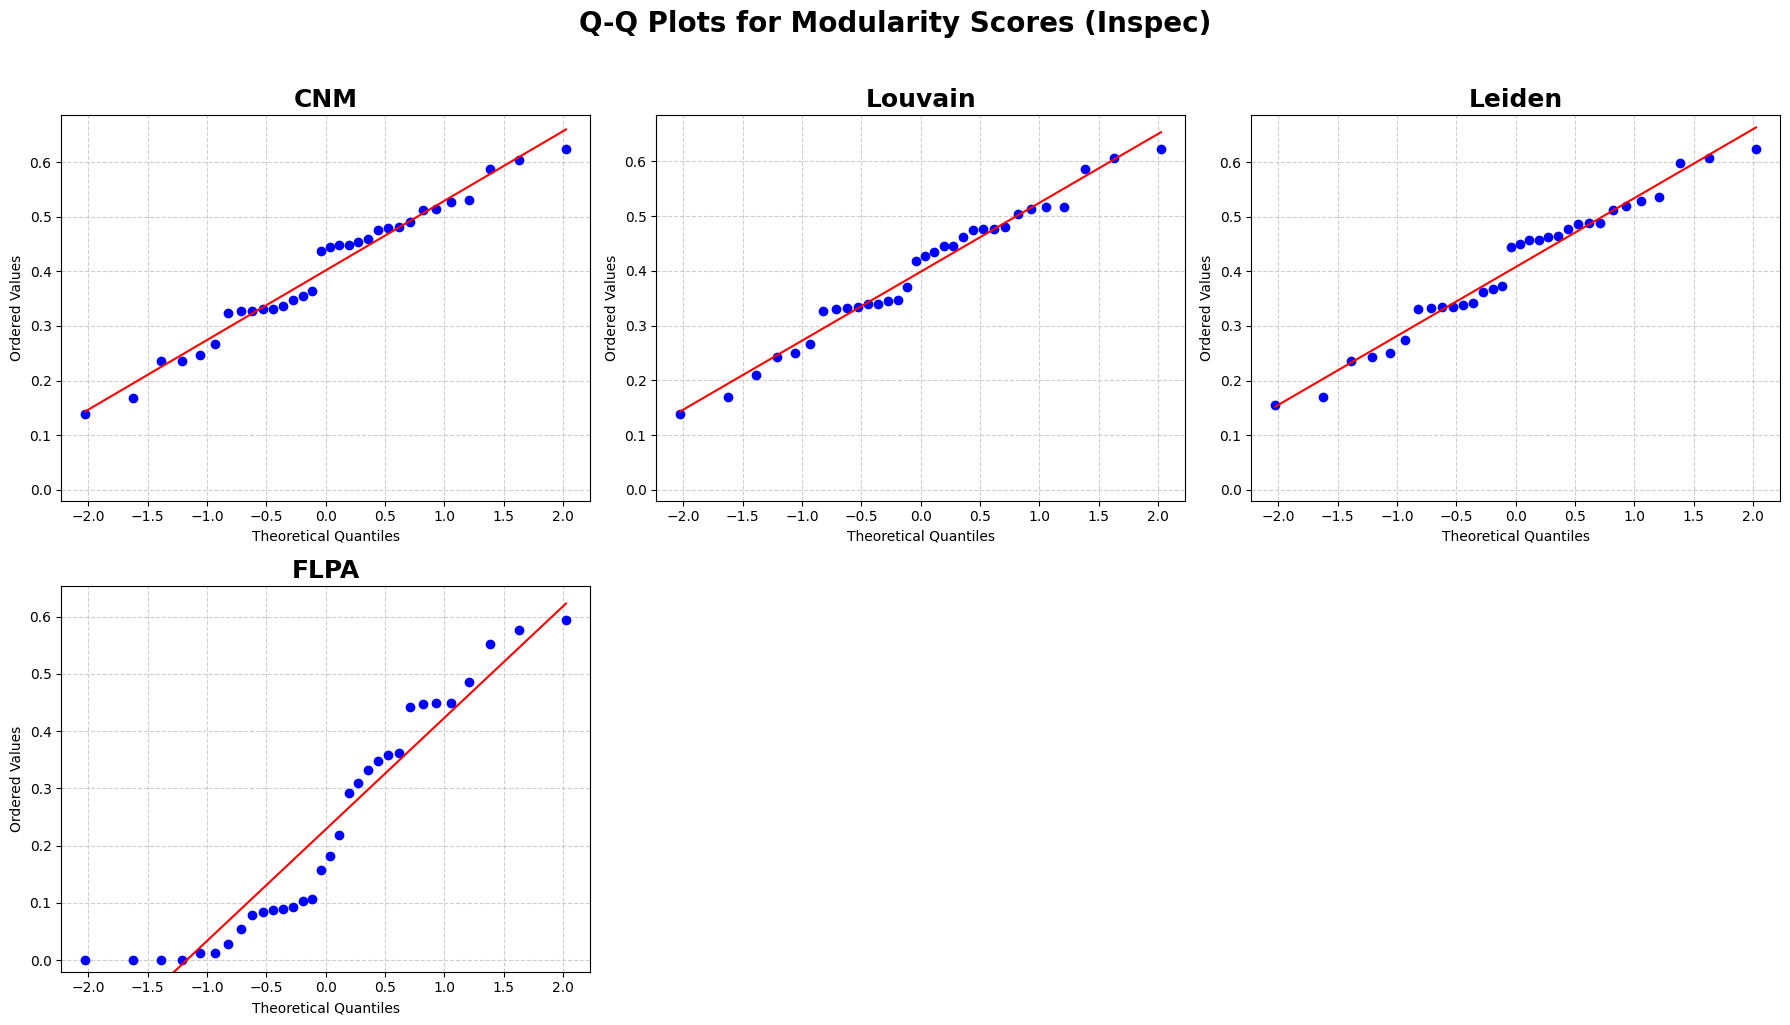

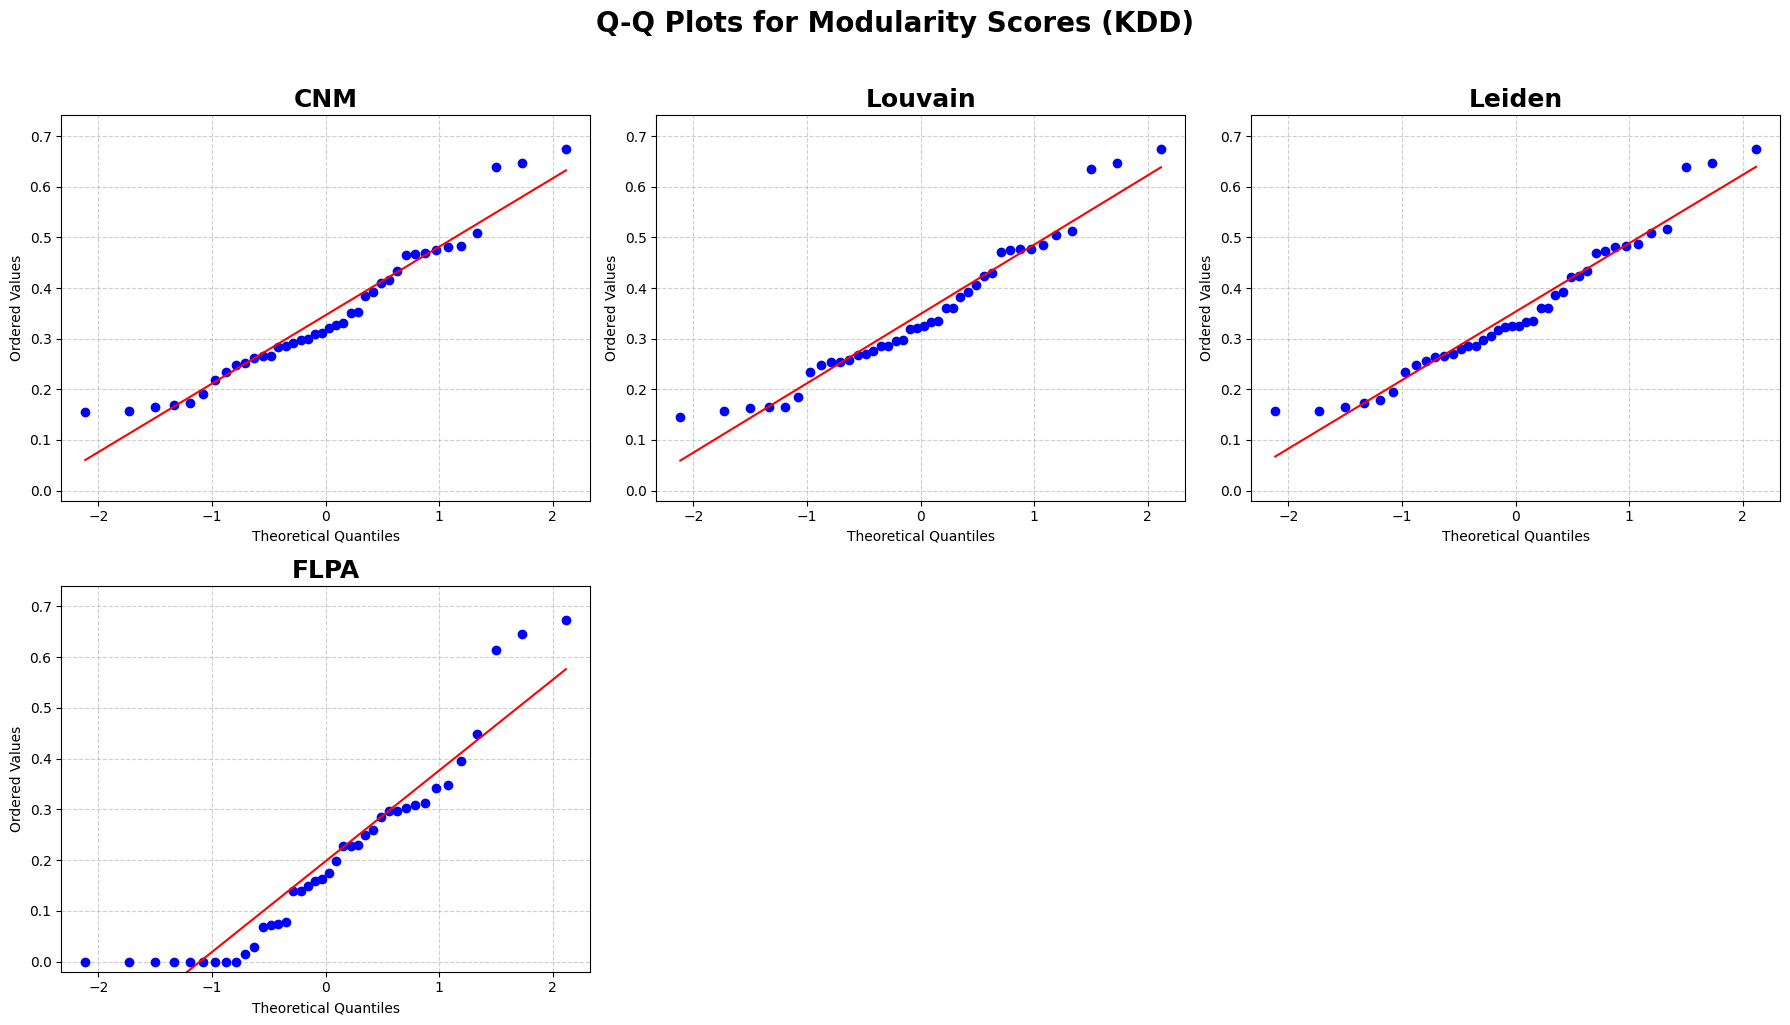

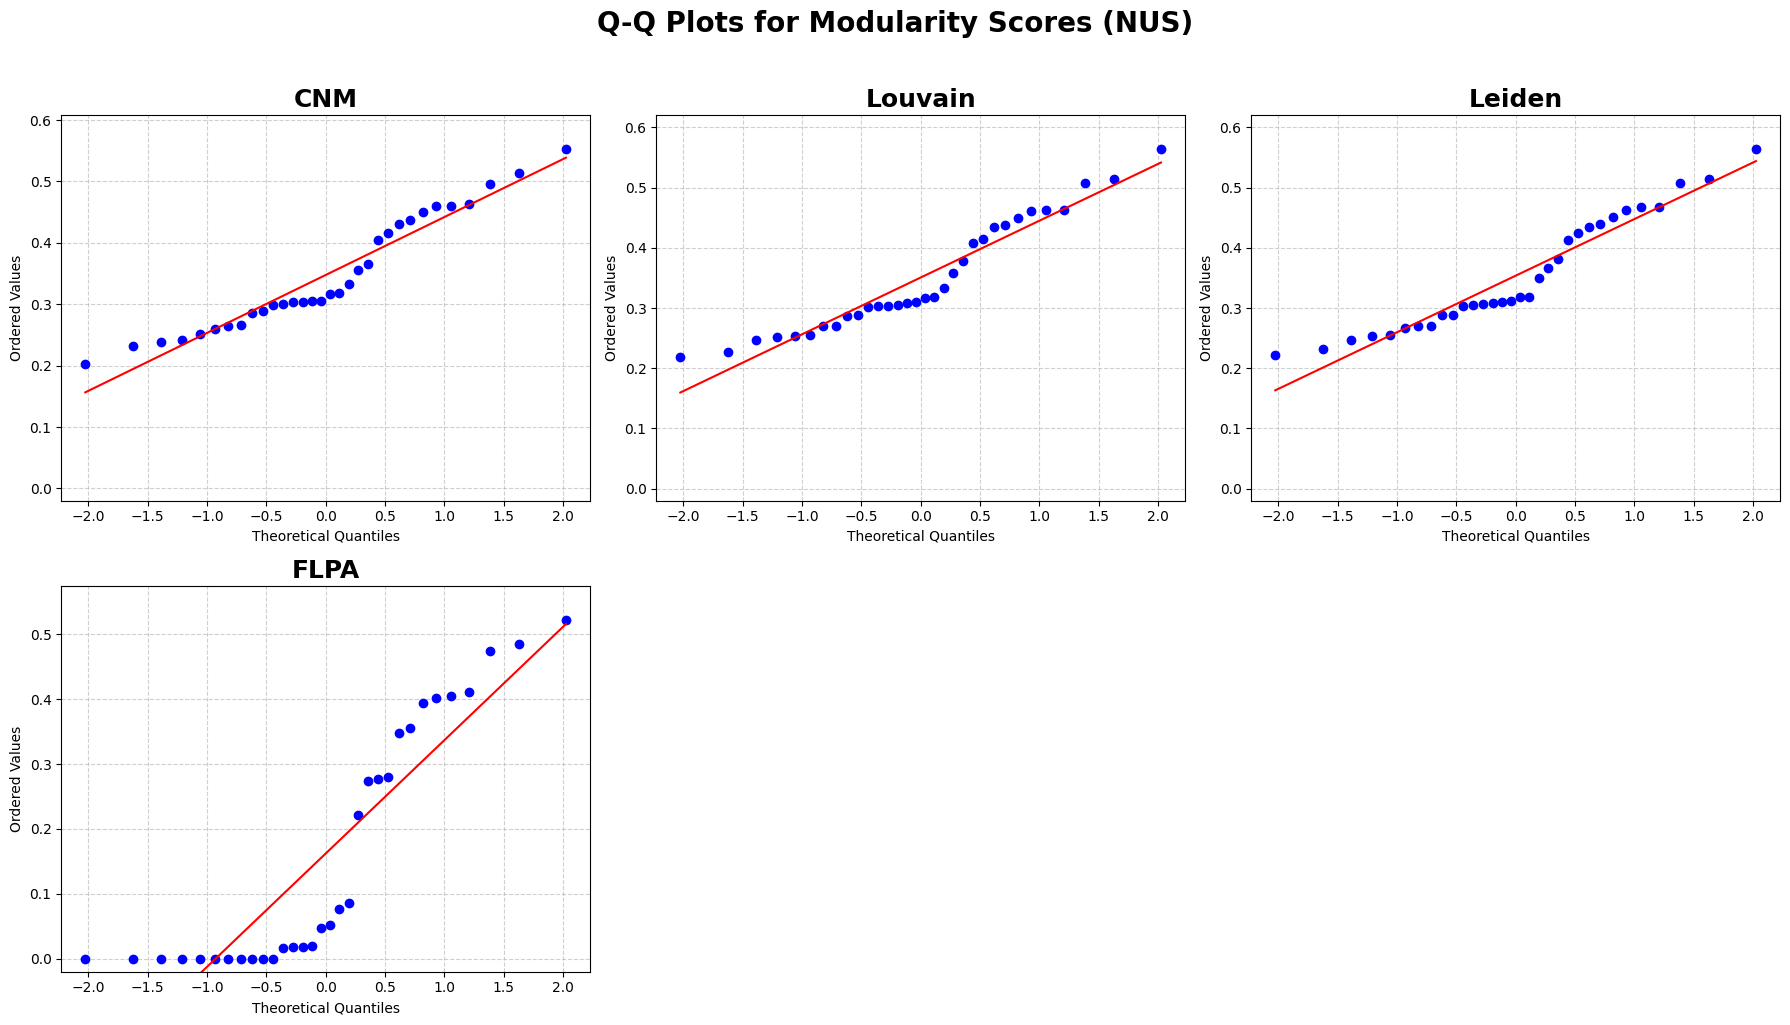

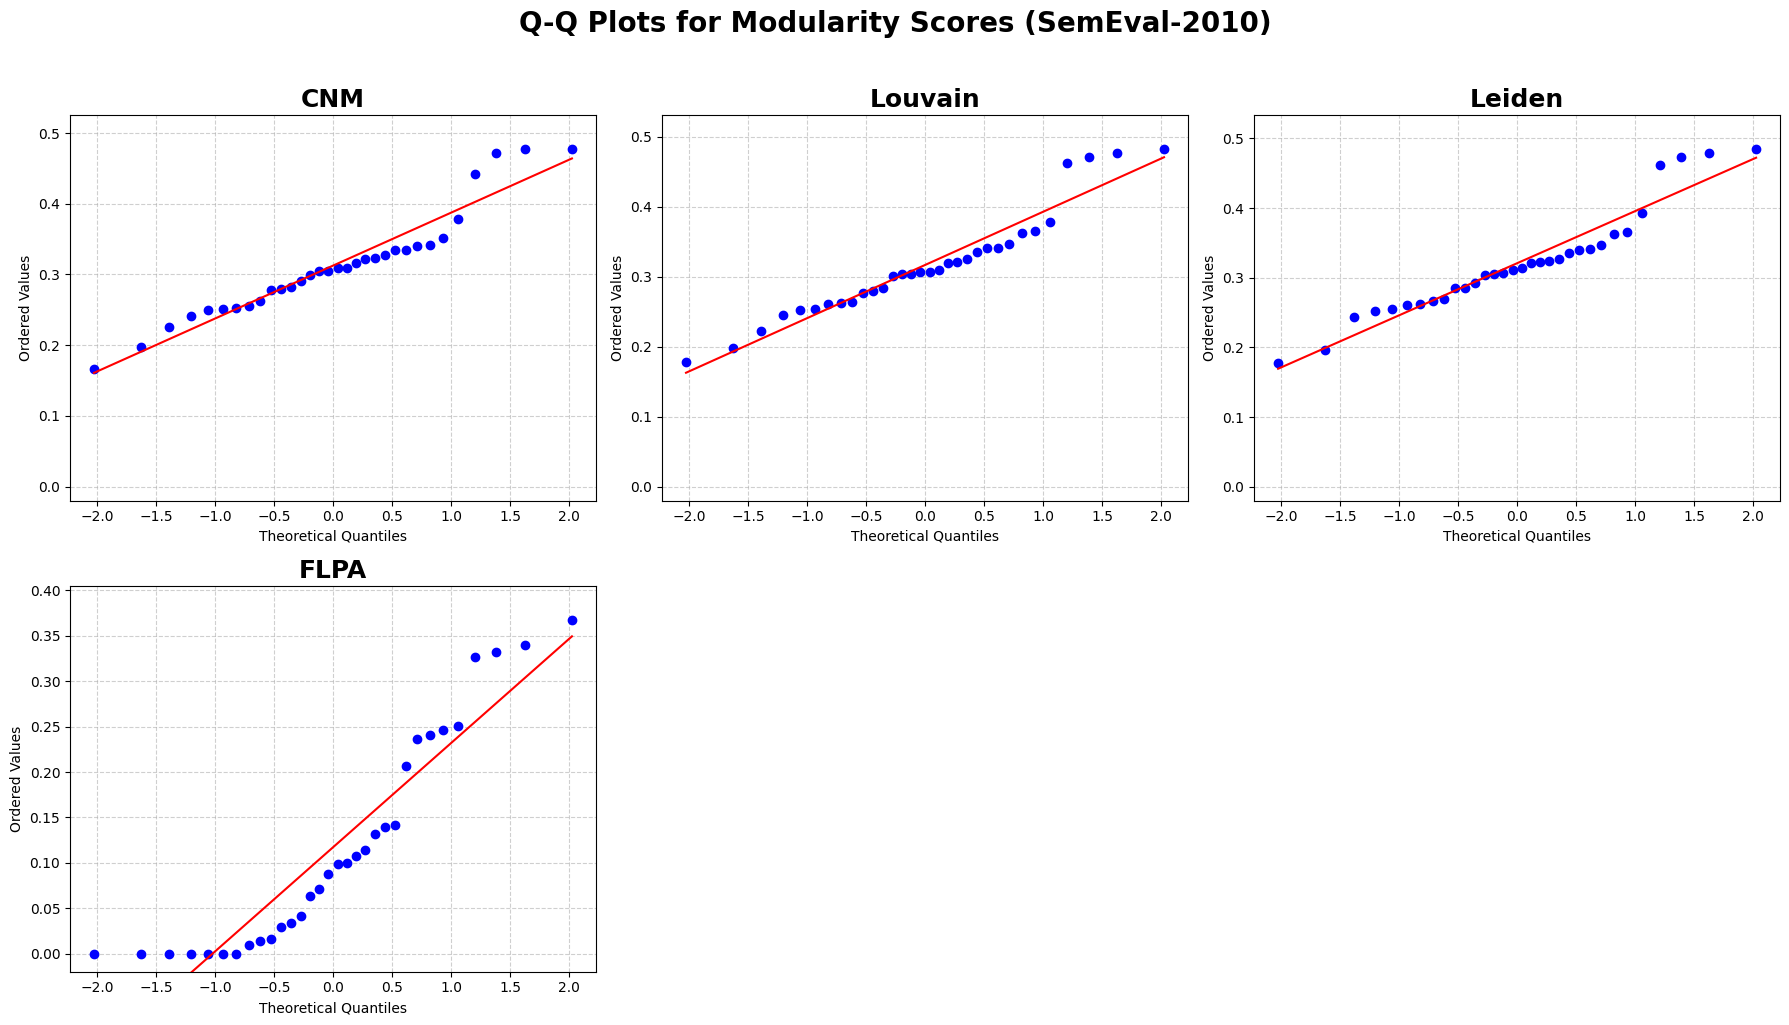

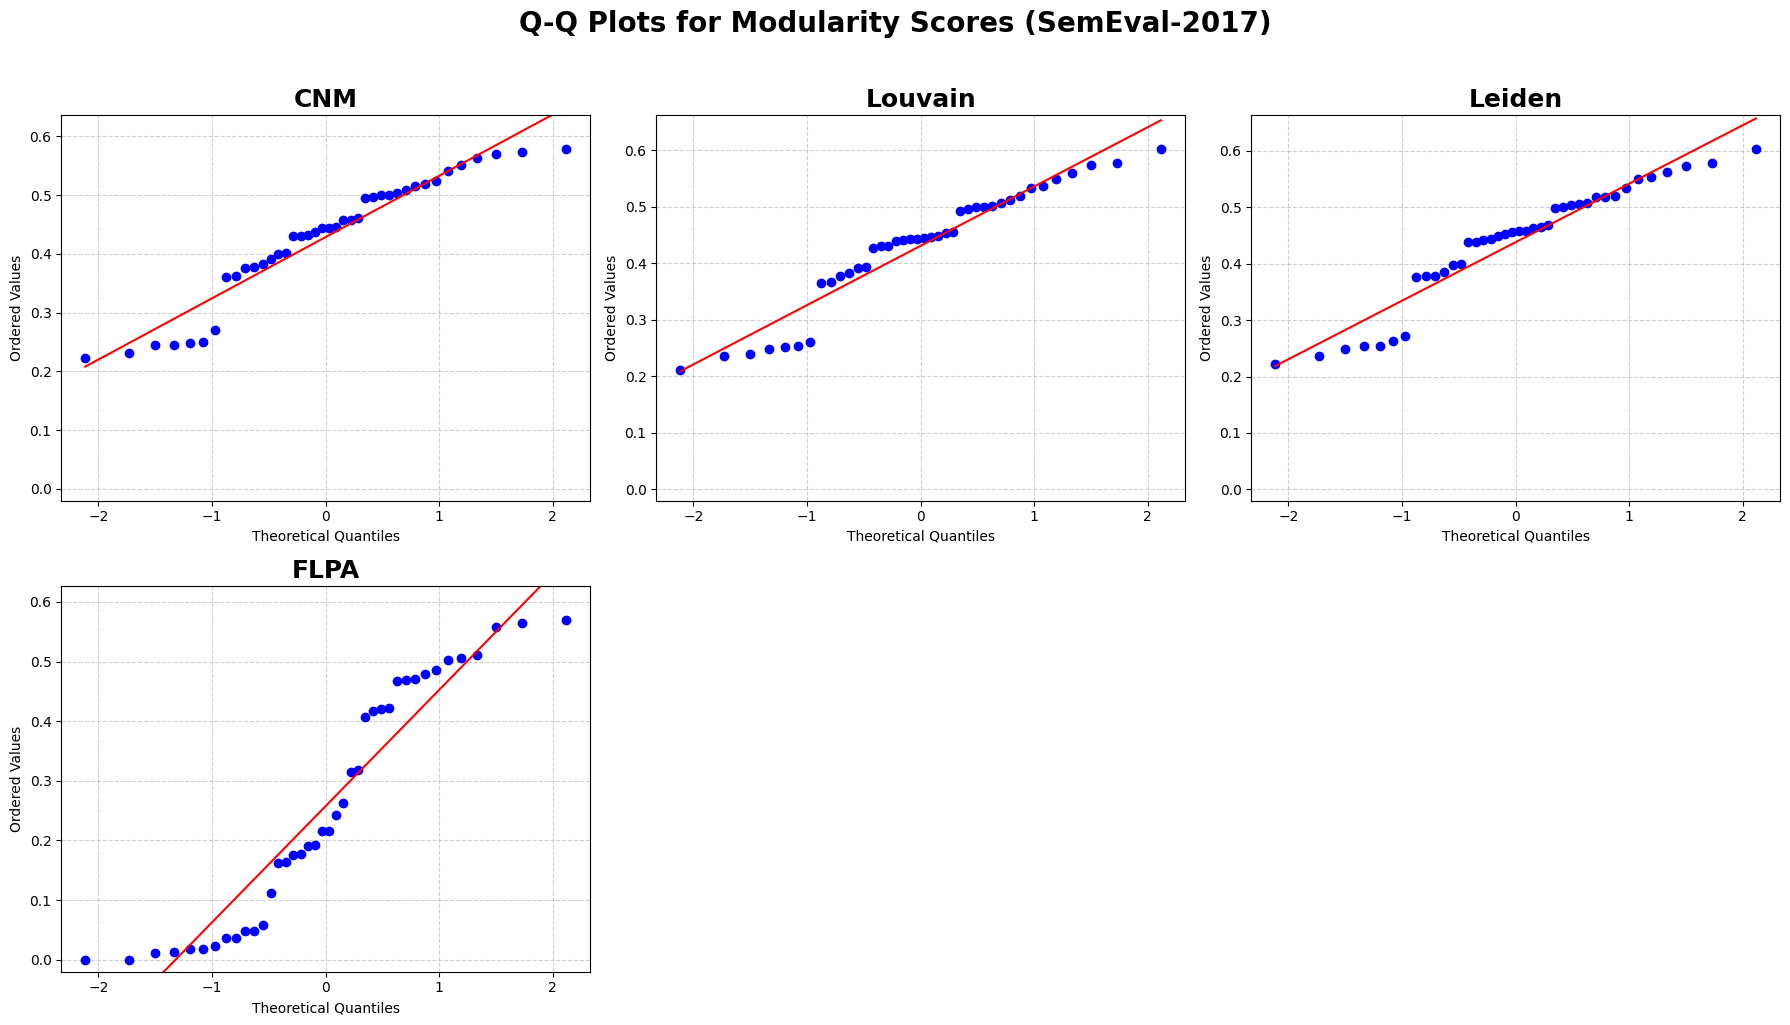

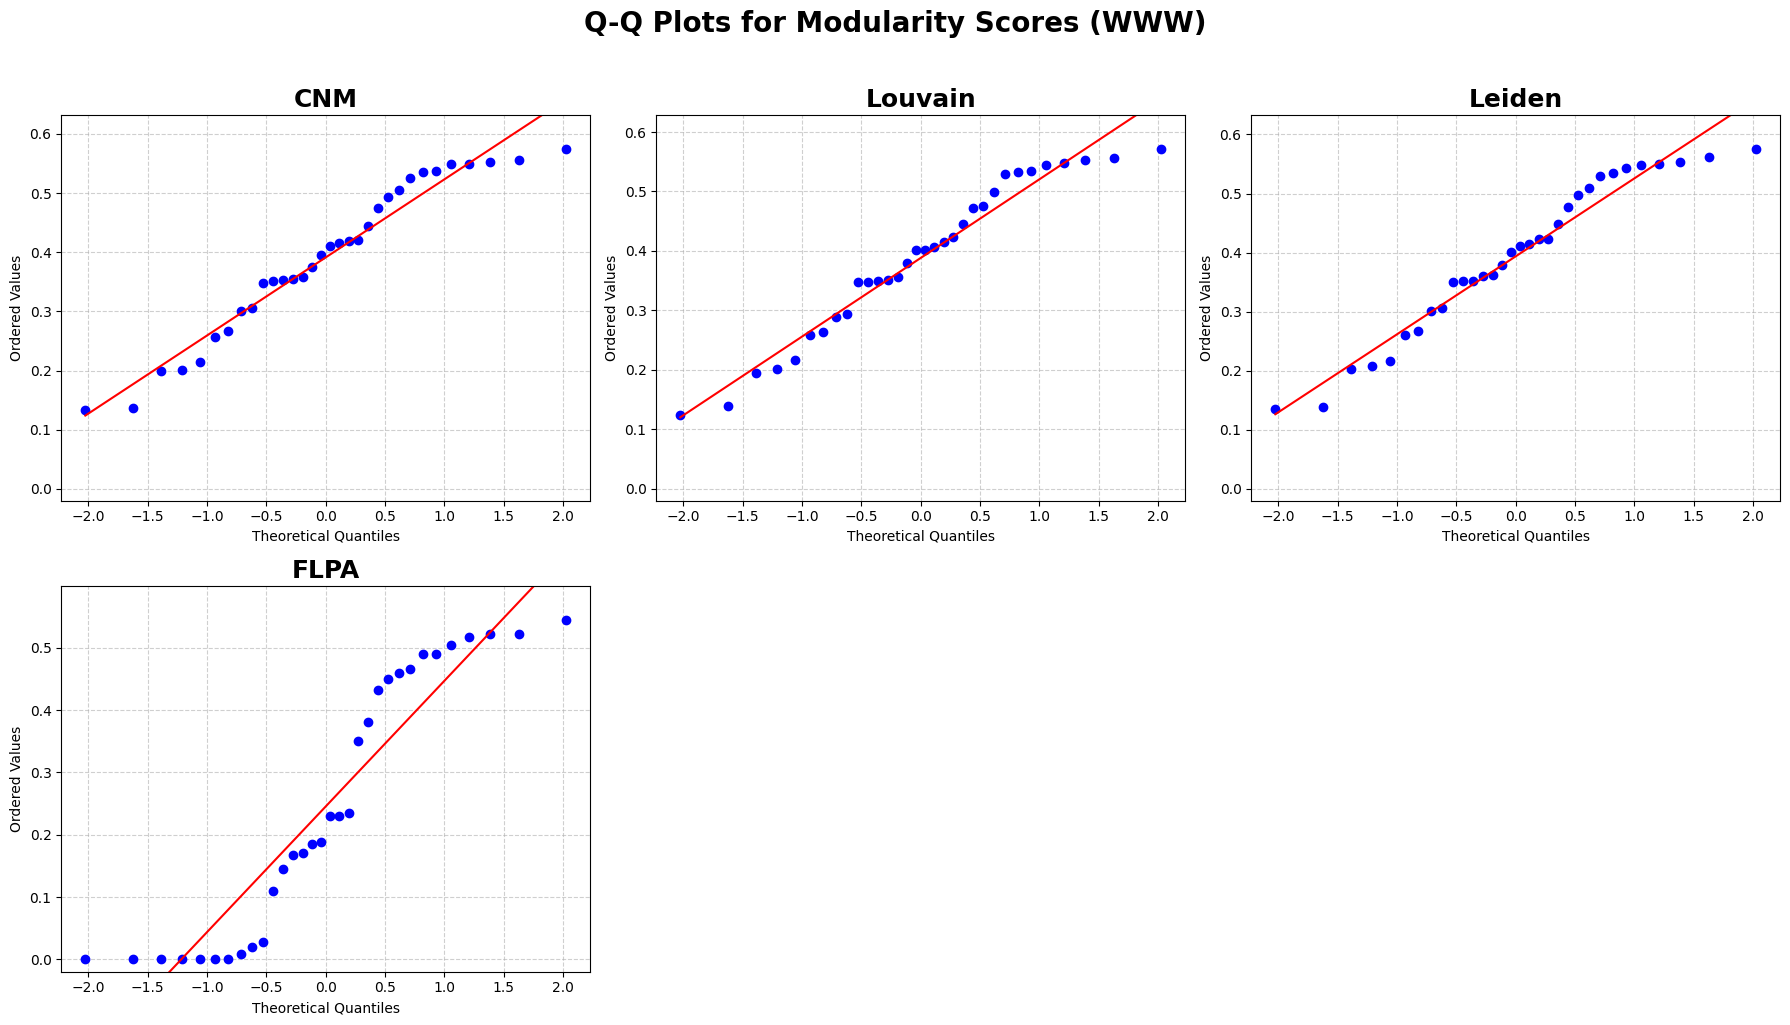

In [ ]:
for dataset, group in Community_Detection_results.groupby('Dataset'):
    algorithms = group['Algorithm'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    fig.suptitle(f"Q-Q Plots for Modularity Scores ({dataset})", fontsize=20, y=1.02, fontweight='bold')

    axes_flat = axes.flatten()

    for i, algorithm in enumerate(algorithms):
        ax = axes_flat[i]
        observations = group[group['Algorithm'] == algorithm]['Modularity']

        if observations.nunique() < 2:
            osm, osr = stats.probplot(observations, dist="norm", fit=False)
            ax.scatter(osm, osr, color='blue', alpha=0.7)
        else:
            stats.probplot(observations, dist="norm", plot=ax)

        ax.set_ylim(-0.02, max(observations) * 1.1 if max(observations) > 0 else 0.1)
        ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

        ax.set_title(f"{algorithm}", fontsize=18, fontweight='semibold')
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Ordered Values")

    for j in range(4, 6):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

# 95% Bootstrap Confidence Interval

In [ ]:
def get_bootstrap_ci(observations, n_bootstrap=10000, ci=95, seed=2026):
    scores = observations.values
    n = len(scores)

    original_mean = np.mean(scores)

    rng = np.random.default_rng(seed)
    resamples = rng.choice(scores, size=(n_bootstrap, n), replace=True)
    resampled_means = resamples.mean(axis=1)

    bootstrap_mean = np.mean(resampled_means)

    bootstrap_bias = bootstrap_mean - original_mean

    lower = np.percentile(resampled_means, (100 - ci) / 2)
    upper = np.percentile(resampled_means, 100 - (100 - ci) / 2)

    return original_mean, bootstrap_mean, lower, upper, bootstrap_bias

In [ ]:
ci_results = []

for ds_name, ds_group in Community_Detection_results.groupby('Dataset'):
    for algo_name, algo_group in ds_group.groupby('Algorithm'):
        observations = algo_group['Modularity']

        original_mean, bootstrap_mean, lower, upper, bootstrap_bias = get_bootstrap_ci(observations)
        ci_results.append({
            'Dataset': ds_name,
            'Algorithm': algo_name,
            'Original Mean': original_mean,
            'Bootstrap Mean': bootstrap_mean,
            'CI Lower': lower,
            'CI Upper': upper,
            'Bootstrap Bias': bootstrap_bias
        })

ci_df = pd.DataFrame(ci_results)

/tmp/ipython-input-379/2792183522.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for algo_name, algo_group in ds_group.groupby('Algorithm'):


In [ ]:
ci_df

,Dataset,Algorithm,Original Mean,Bootstrap Mean,CI Lower,CI Upper,Bootstrap Bias
0,500N-KP-Crowd,CNM,0.405741,0.405487,0.361918,0.448917,-0.000254
1,500N-KP-Crowd,Louvain,0.405718,0.405441,0.360482,0.450067,-0.000277
2,500N-KP-Crowd,Leiden,0.409568,0.409299,0.365245,0.453240,-0.000269
3,500N-KP-Crowd,FLPA,0.303391,0.302966,0.237629,0.368508,-0.000425
4,DUC-2001,CNM,0.429415,0.429085,0.369944,0.490550,-0.000329
5,DUC-2001,Louvain,0.430326,0.429988,0.370796,0.491271,-0.000339
6,DUC-2001,Leiden,0.434797,0.434465,0.376103,0.495208,-0.000333
7,DUC-2001,FLPA,0.293788,0.293322,0.201937,0.387617,-0.000466
8,Inspec,CNM,0.401566,0.401505,0.357772,0.443660,-0.000061
9,Inspec,Louvain,0.398178,0.398111,0.354905,0.439762,-0.000067


In [ ]:
import string

alphabet = list(string.ascii_lowercase)
dataset_order = ['SemEval-2010', 'NUS', 'Inspec', 'KDD', 'WWW', 'SemEval-2017', 'DUC-2001', '500N-KP-Crowd']

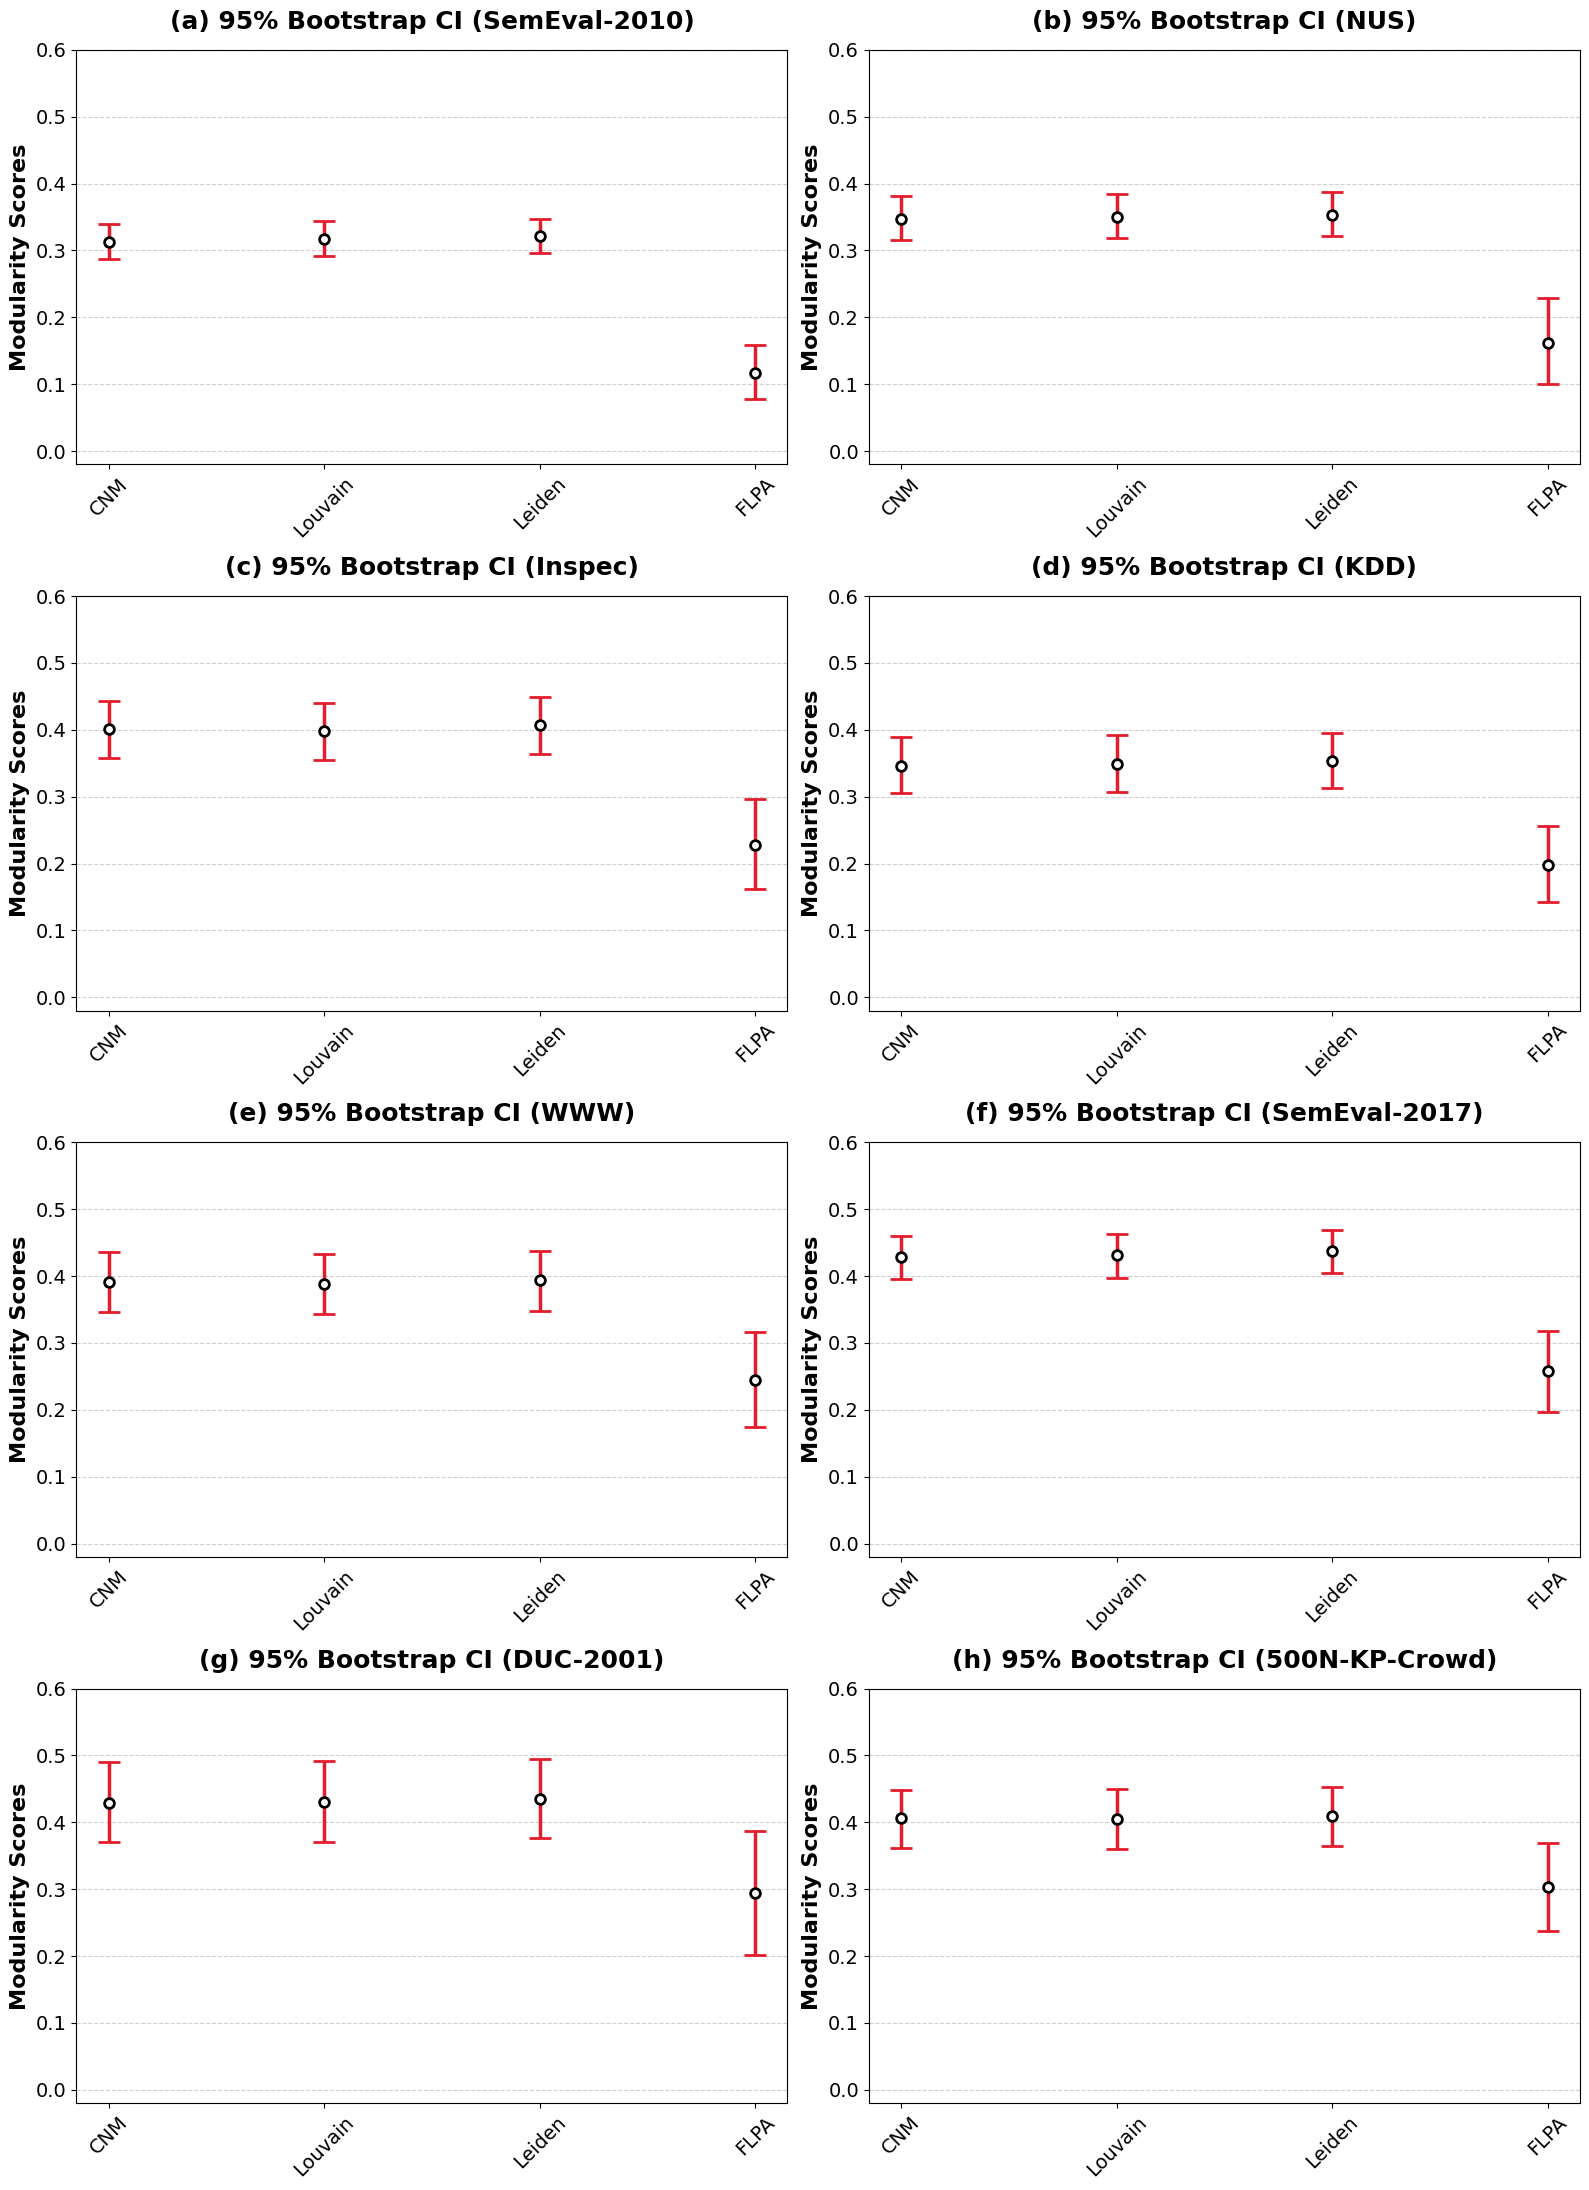

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes_flat = axes.flatten()

for i, ds_name in enumerate(dataset_order):
    ax = axes_flat[i]
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylim(-0.02, 0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    instance = ci_df[ci_df['Dataset'] == ds_name]

    yerr = [instance['Original Mean'] - instance['CI Lower'], instance['CI Upper'] - instance['Original Mean']]

    ax.errorbar(x=instance['Algorithm'], y=instance['Original Mean'], yerr=yerr,
                fmt='o', color='black', ecolor='#E31D2B', capsize=8,
                elinewidth=2.5, mfc='white', ms=7, mew=2)

    ax.set_title(f"({alphabet[i]}) 95% Bootstrap CI ({ds_name})", fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel("Modularity Scores", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Friedman Test & Nemeiny Posthoc Test

In [ ]:
!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp

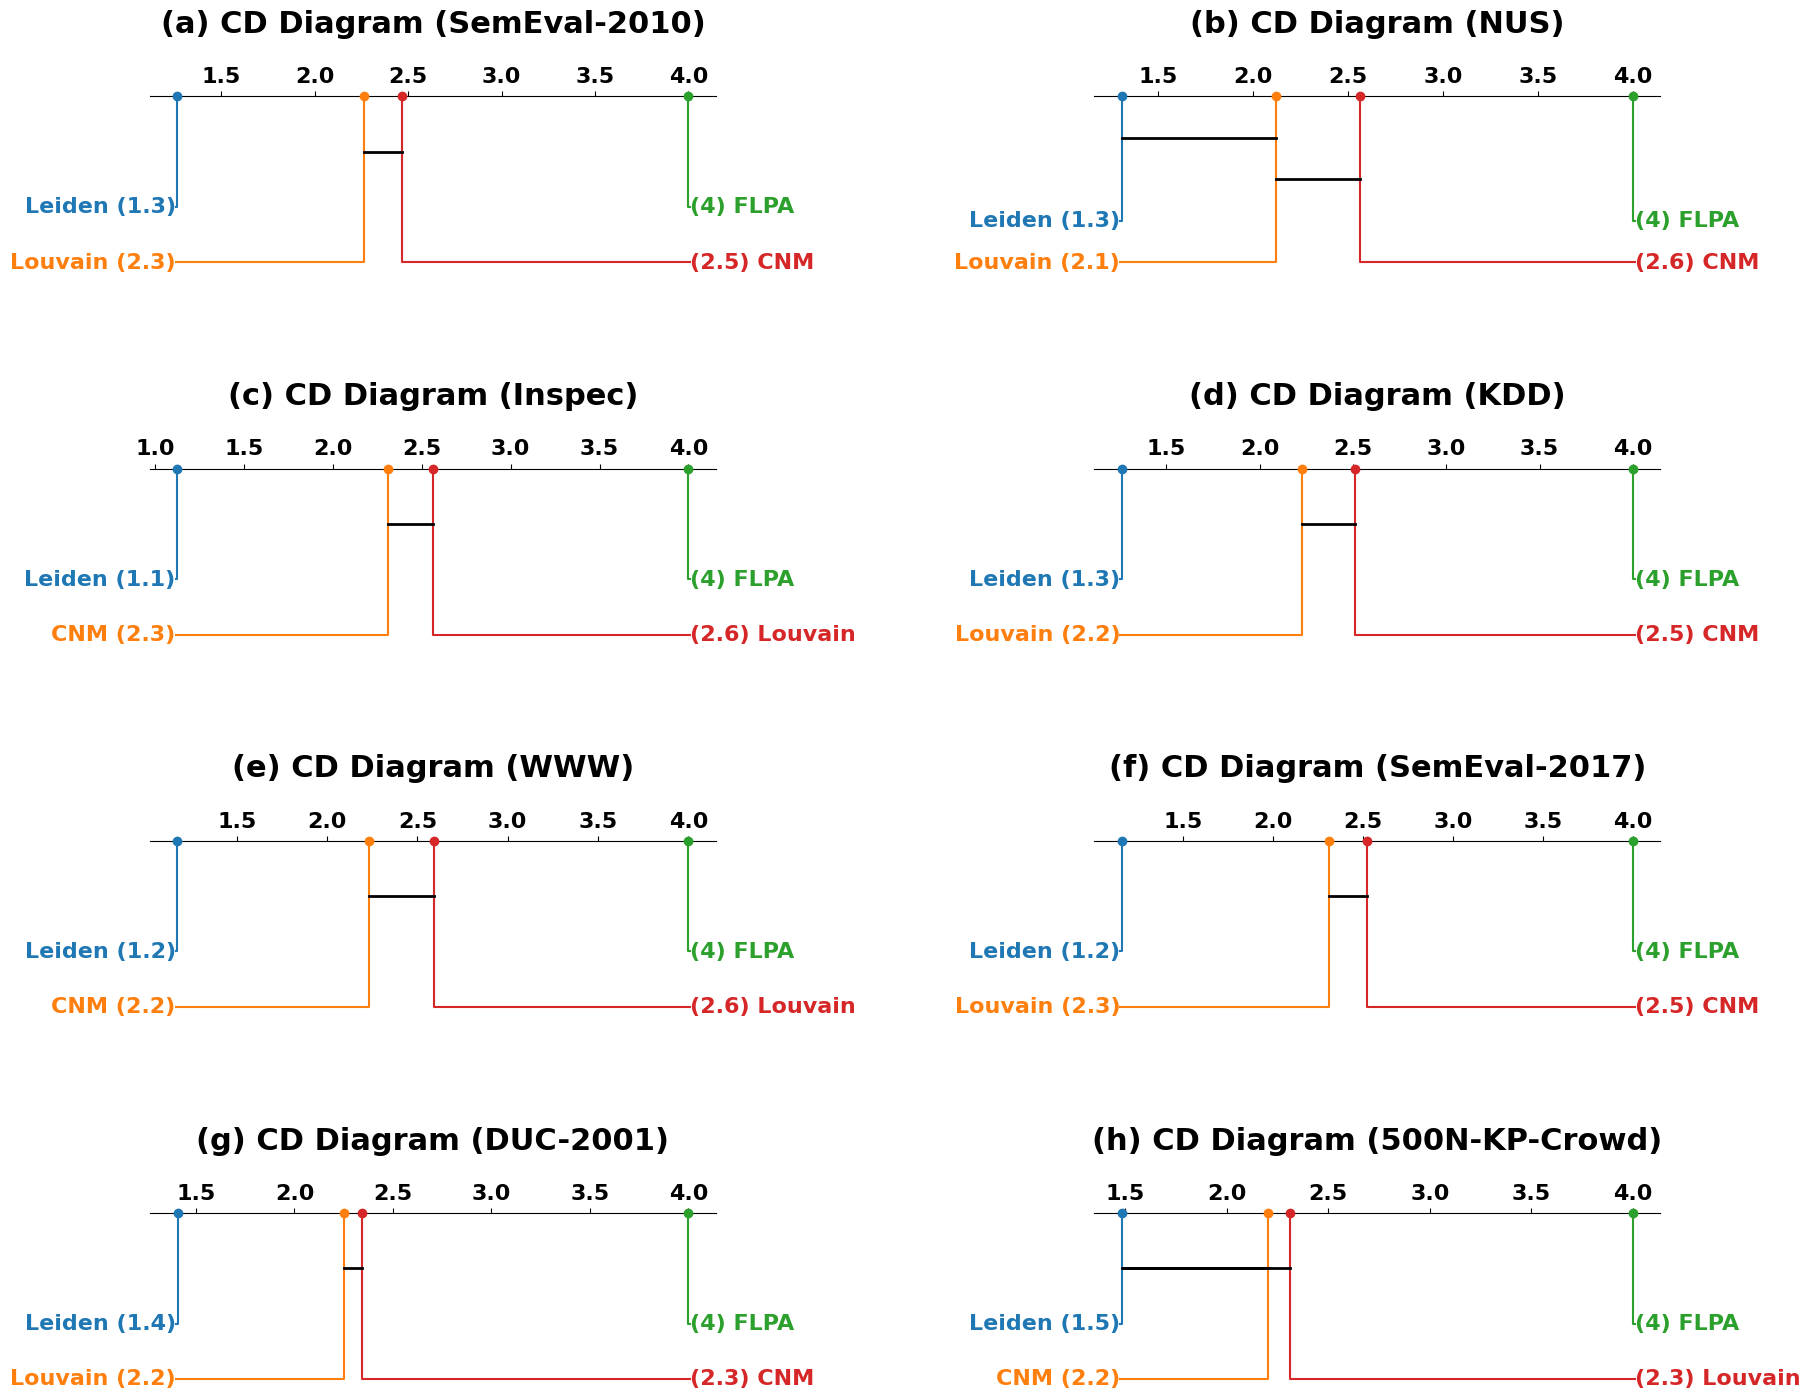

In [ ]:
friedman_results = []
posthoc_matrices = {}

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes_flat = axes.flatten()

plt.rcParams.update({
    'axes.titleweight': 'bold',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'font.size': 16,
    'xtick.labelsize': 16
})

for i, ds_name in enumerate(dataset_order):
    ax = axes_flat[i]

    group = Community_Detection_results[Community_Detection_results['Dataset'] == ds_name].pivot_table(
        index=['Method', 'Measure'],
        columns='Algorithm',
        values='Modularity',
        observed=True)

    temp_group = group.copy()
    temp_group.index = temp_group.index.map(lambda x: f"{x[0]}_{x[1]}")

    algorithms = temp_group.columns.tolist()
    stat, p_val_legacy = stats.friedmanchisquare(*[temp_group[algo] for algo in algorithms])

    n = len(temp_group)
    k = len(algorithms)

    f_stat = ((n - 1) * stat) / (n * (k - 1) - stat)
    p_val = stats.f.sf(f_stat, k - 1, (k - 1) * (n - 1))

    friedman_results.append({
        'Dataset': ds_name,
        'Friedman Stat': stat,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

    if p_val < 0.05:
        posthoc_df = sp.posthoc_nemenyi_friedman(temp_group)
        posthoc_matrices[ds_name] = posthoc_df

        group_rank_df = temp_group.rank(axis=1, ascending=False)
        group_avg_ranks = group_rank_df.mean()

        plt.sca(ax)
        sp.critical_difference_diagram(group_avg_ranks, posthoc_df)

        ax.set_title(f"({alphabet[i]}) CD Diagram ({ds_name})",
                    pad=40, fontsize=22, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f"({alphabet[i]}) No significant difference found\nfor {ds_name}.",
                ha='center', va='center', fontsize=16)
        ax.axis('off')

plt.tight_layout(pad=5.0)

plt.show()

plt.rcdefaults()

friedman_df = pd.DataFrame(friedman_results)

In [ ]:
friedman_df

,Dataset,Friedman Stat,p-value,Significant
0,SemEval-2010,78.430000,3.573219e-34,Yes
1,NUS,76.143322,1.041287e-31,Yes
2,Inspec,81.523810,4.464648e-38,Yes
3,KDD,96.179221,6.478482e-41,Yes
4,WWW,79.838095,7.410405e-36,Yes
5,SemEval-2017,99.534351,9.158734e-45,Yes
6,DUC-2001,73.586441,2.860549e-29,Yes
7,500N-KP-Crowd,69.963211,2.963827e-26,Yes


In [ ]:
posthoc_matrices['KDD']

,CNM,Louvain,Leiden,FLPA
CNM,1.000000,7.517416e-01,0.000088,1.532730e-06
Louvain,0.751742,1.000000e+00,0.004746,4.682191e-09
Leiden,0.000088,4.745878e-03,1.000000,0.000000e+00
FLPA,0.000002,4.682191e-09,0.000000,1.000000e+00


# Extract Requirements

In [ ]:
!pip freeze > Community_Detection.txt